In [0]:
# Verify required packages are available
# (Packages are already installed in this environment)

try:
    import xgboost
    import shap
    import mlflow
    import skopt
    import category_encoders
    
    print("✅ All required packages are available:")
    print(f"  - xgboost: {xgboost.__version__}")
    print(f"  - shap: {shap.__version__}")
    print(f"  - mlflow: {mlflow.__version__}")
    print(f"  - scikit-optimize: {skopt.__version__}")
    print(f"  - category_encoders: {category_encoders.__version__}")
    print("\n✅ Environment ready for ML fraud detection workflow")
    
except ImportError as e:
    print(f"❌ Missing package: {e}")
    print("\nTo install, run: %pip install xgboost shap mlflow scikit-optimize category_encoders")

✅ All required packages are available:
  - xgboost: 3.2.0
  - shap: 0.51.0
  - mlflow: 3.10.1
  - scikit-optimize: 0.10.2
  - category_encoders: 2.8.1

✅ Environment ready for ML fraud detection workflow


In [0]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import IsolationForest

from xgboost import XGBClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Integer

import shap
import mlflow
import mlflow.sklearn

In [0]:
# Initialize Spark session
from pyspark.sql import SparkSession

# Get or create Spark session
spark = SparkSession.builder.getOrCreate()
print(f"✅ Spark session initialized (version {spark.version})")

# Load using Spark (Faster, no need for complex pathing)
spark_df = spark.read.format("csv").option("header", "true").load("/Volumes/workspace/default/finaldata/final_ap_dataset.csv")

# Convert to Pandas for your AI model
df = spark_df.toPandas()

print(f"\n✅ Loaded {df.shape[0]:,} rows with {df.shape[1]} columns")
df.head()

---------------------------------------------------------------------------
PySparkValueError                         Traceback (most recent call last)
File <command-6179682269653978>, line 5
      2 from pyspark.sql import SparkSession
      4 # Get or create Spark session
----> 5 spark = SparkSession.builder.getOrCreate()
      6 print(f"✅ Spark session initialized (version {spark.version})")
      8 # Load using Spark (Faster, no need for complex pathing)

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/session.py:548, in SparkSession.Builder.getOrCreate(self)
    544     os.environ["SPARK_CONNECT_MODE_ENABLED"] = "1"
    545     opts["spark.remote"] = url
    546     return cast(
    547         SparkSession,
--> 548         RemoteSparkSession.builder.config(map=opts).getOrCreate(),
    549     )
    550 elif "SPARK_LOCAL_REMOTE" in os.environ:
    551     url = "sc://localhost"

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/session.py:28

In [0]:
# 1. Convert the date column to datetime handling mixed formats safely
df["date"] = pd.to_datetime(df["date"], format='mixed', dayfirst=False)

# 2. Convert numeric columns from strings to appropriate types
numeric_cols = ['amount', 'duplicate_flag', 'invoice_count', 'avg_amount', 'weekend_flag']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Extract features from the now-standardized date column
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

# Business flags
df["high_amount_flag"] = (df["amount"] > (df["avg_amount"] * 3)).astype(int)

# 1. Weekend Warrior
df["is_weekend"] = df["date"].dt.dayofweek.isin([5,6]).astype(int)

# 2. Bank Account Flip (simulated)
df["bank_change_flag"] = np.random.choice([0,1], len(df), p=[0.95,0.05])

# 3. Ghost Vendor (simulated)
df["ghost_vendor_flag"] = np.random.choice([0,1], len(df), p=[0.98,0.02])

# 4. Velocity Spike
vendor_counts = df.groupby("vendor_id")["invoice_id"].transform("count")
df["velocity_spike"] = (vendor_counts > vendor_counts.mean()*3).astype(int)

# 5. Benford Law Feature
df["first_digit"] = df["amount"].astype(str).str[0].astype(int)

benford_dist = {1:0.301,2:0.176,3:0.125,4:0.097,5:0.079,6:0.067,7:0.058,8:0.051,9:0.046}
df["benford_score"] = df["first_digit"].map(benford_dist)



In [0]:
features = [
    "amount","avg_amount","invoice_count",
    "duplicate_flag","is_weekend","bank_change_flag",
    "ghost_vendor_flag","velocity_spike",
    "benford_score","high_amount_flag",
    "day_of_week","month"
]

X = df[features]
y = df["fraud_label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [0]:
#XGBOOST + BAYESSEARCH
# Optimized search space - removed invalid clf__ prefix and focused on key parameters
search_space = {
    'max_depth': Integer(3, 8),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'subsample': Real(0.7, 1.0),
    'colsample_bytree': Real(0.7, 1.0),
    'n_estimators': Integer(100, 300),
    'reg_alpha': Real(0.0, 5.0),
    'reg_lambda': Real(0.0, 5.0)
}

xgb = XGBClassifier(eval_metric="auc", random_state=42)

opt = BayesSearchCV(
    estimator=xgb,
    search_spaces=search_space,
    n_iter=8,  # Reduced from 15 to 8
    scoring='roc_auc',
    cv=2,  # Reduced from 3 to 2 folds
    random_state=42,
    verbose=1
)

opt.fit(X_train, y_train)

model = opt.best_estimator_

y_prob = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

print("\nBest Parameters:", opt.best_params_)
print("\nXGBoost AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits

Best Parameters: OrderedDict({'colsample_bytree': 0.943718796507209, 'learning_rate': 0.0167343965754388, 'max_depth': 6, 'n_estimators': 261, 'reg_alpha': 2.615261640271918, 'reg_lambda': 0.47727519607496727, 'subsample': 0.9267401598507645})

XGBoost AUC: 0.9083262110647863
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1428973
           1       0.89      0.00      0.00      5772

    accuracy                           1.00   1434745
   macro avg       0.94      0.5

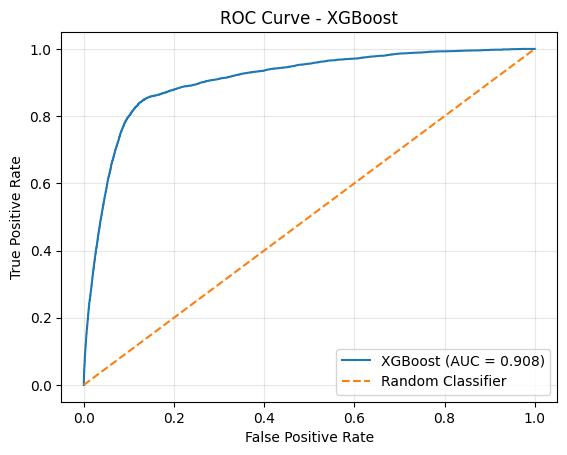

'\nThe Area Under the Curve (AUC) is 0.909.\n\n0.90+ is Excellent: It means there is a 90.9% chance that the model will rank a randomly chosen fraudulent invoice higher (more suspicious) than a randomly chosen normal invoice.\n\nThe model is performing significantly better than a "Random Classifier" (the orange dashed line), which would just be guessing 50/50.\n'

In [0]:
#XGBOOST + BAYESSEARCH
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = opt.best_estimator_.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test.astype(int), y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

"""
The Area Under the Curve (AUC) is 0.909.

0.90+ is Excellent: It means there is a 90.9% chance that the model will rank a randomly chosen fraudulent invoice higher (more suspicious) than a randomly chosen normal invoice.

The model is performing significantly better than a "Random Classifier" (the orange dashed line), which would just be guessing 50/50.
"""

<Figure size 1000x800 with 0 Axes>

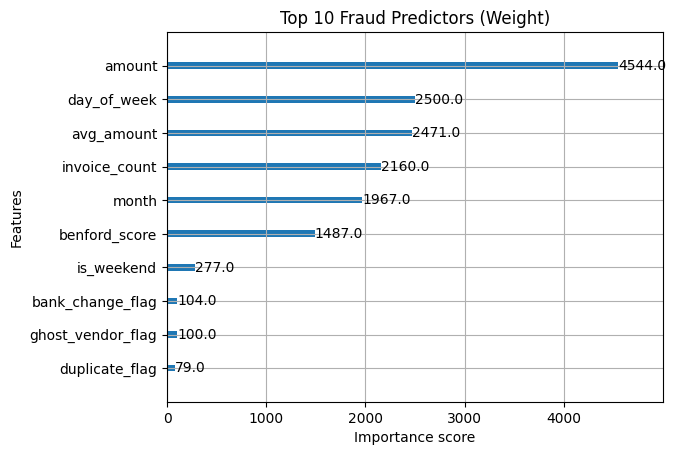

<Figure size 1000x800 with 0 Axes>

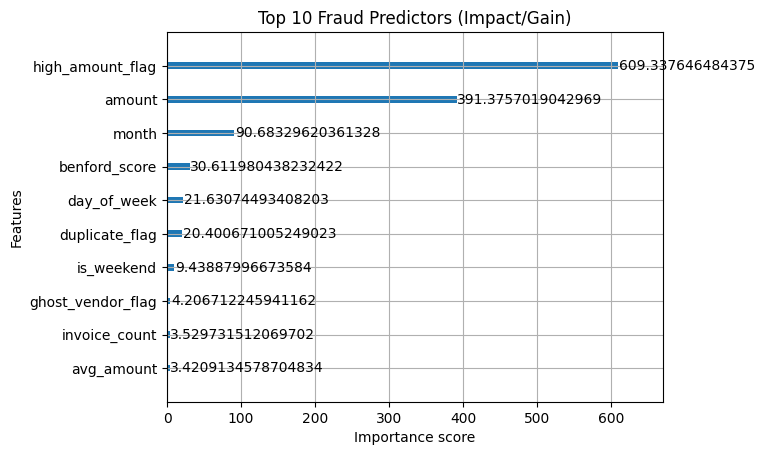

'\nThe model has successfully learned that High Amounts compared to the Average Amount are the strongest indicators of suspicious activity.\n'

In [0]:
#FEATURE IMPORTANCE GRAPH
import matplotlib.pyplot as plt
from xgboost import plot_importance

# 1. Plotting using the 'weight' (number of times a feature appears in trees)
plt.figure(figsize=(10, 8))
plot_importance(opt.best_estimator_, max_num_features=10, importance_type='weight')
plt.title("Top 10 Fraud Predictors (Weight)")
plt.show()

# 2. Plotting using 'gain' (the average improvement in accuracy brought by a feature)
# 'Gain' is usually better for business interpretation
plt.figure(figsize=(10, 8))
plot_importance(opt.best_estimator_, max_num_features=10, importance_type='gain')
plt.title("Top 10 Fraud Predictors (Impact/Gain)")
plt.show()

"""
The model has successfully learned that High Amounts compared to the Average Amount are the strongest indicators of suspicious activity.
"""

In [0]:
# 1. Get the probability of fraud for every row
# This gives a score between 0 and 1
df['fraud_probability'] = opt.best_estimator_.predict_proba(X)[:, 1]

# 2. Filter for high-probability cases (e.g., > 80% certain)
top_suspects = df[df['fraud_probability'] > 0.8].sort_values(by='fraud_probability', ascending=False)

# 3. View the top 20 most suspicious invoices
# We include the original IDs so you can go back to SAP/CSV
print("--- TOP 20 FRAUD SUSPECTS ---")
print(top_suspects[['invoice_id', 'vendor_id', 'amount', 'avg_amount', 'fraud_probability', 'fraud_label']].head(20))

--- TOP 20 FRAUD SUSPECTS ---
Empty DataFrame
Columns: [invoice_id, vendor_id, amount, avg_amount, fraud_probability, fraud_label]
Index: []


In [0]:
#XGBOOST + BAYESSEARCH
import pandas as pd

importance = opt.best_estimator_.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

,feature,importance
9,high_amount_flag,0.512991
0,amount,0.329492
11,month,0.076345
8,benford_score,0.025772
10,day_of_week,0.018211
3,duplicate_flag,0.017175
4,is_weekend,0.007946
6,ghost_vendor_flag,0.003542
2,invoice_count,0.002972
1,avg_amount,0.002880


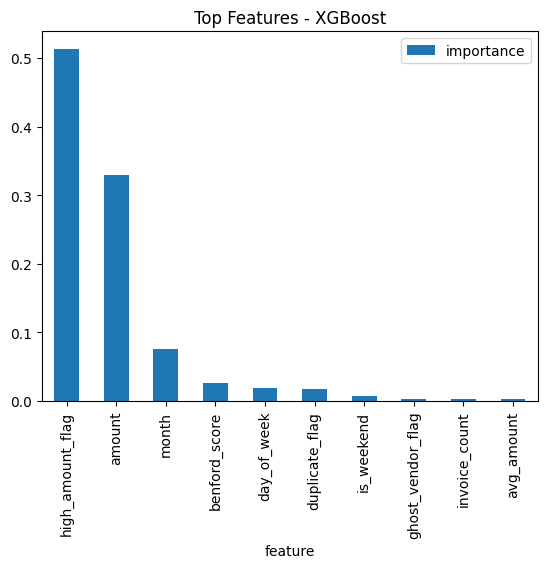

In [0]:
#XGBOOST + BAYESSEARCH
feat_imp.head(10).plot(
    x="feature",
    y="importance",
    kind="bar"
)
plt.title("Top Features - XGBoost")
plt.show()

In [0]:
#XGBOOST + BAYESSEARCH
# 1. Get probabilities (Probability of being class 1/Fraud)
# Make sure X has the same rows as your original df
probs = opt.best_estimator_.predict_proba(X)[:, 1]

# 2. Add the score back to your original dataframe for viewing
df['fraud_score'] = probs

# 3. Sort by the highest score first
# We use .iloc because we want the absolute top 20 regardless of the 80% threshold
top_20_list = df.sort_values(by='fraud_score', ascending=False).head(20)

# 4. Display the specific columns for investigation
# If 'invoice_id' was dropped, use df.index
cols_to_show = ['amount', 'avg_amount', 'fraud_score', 'fraud_label']
if 'invoice_id' in df.columns:
    cols_to_show.insert(0, 'invoice_id')
if 'vendor_id' in df.columns:
    cols_to_show.insert(1, 'vendor_id')

print("--- TOP 20 MOST SUSPICIOUS INVOICES ---")
display(top_20_list[cols_to_show])

--- TOP 20 MOST SUSPICIOUS INVOICES ---


invoice_id,vendor_id,amount,avg_amount,fraud_score,fraud_label
1030687,V10199,1.0E7,163292.0663889818,0.5697622,1
3193219,V10533,1.0E7,163234.10071968683,0.5692563,1
5996400,V10426,1.0E7,163749.08987498292,0.55728185,1
5990225,V10726,1.0E7,152818.3123035685,0.5568554,1
6236271,V10207,1.027322528E7,155684.44850395058,0.5555047,0
5990224,V10158,1.0E7,163828.2211961323,0.551967,1
6247197,V10617,1.253869151E7,150549.29699046415,0.55004185,0
6239963,V10921,1.541593831E7,160725.7890386227,0.54937077,0
5996402,V10341,1.0E7,166122.70307861705,0.54933846,1
5987587,V10341,1.0E7,166122.70307861705,0.54933846,1


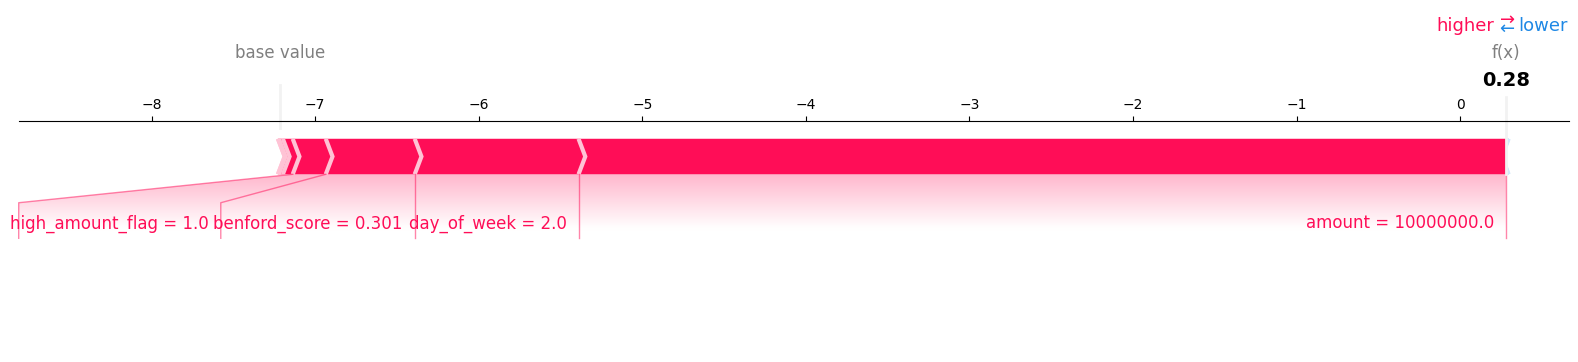

In [0]:
#XGBOOST + BAYESSEARCH +SHAP
import shap
import pandas as pd

# 1. Summarize the background data (100 rows is enough to define "Normal")
X_summary = shap.utils.sample(X, 100) 

# 2. Re-initialize the explainer with the summary
explainer = shap.TreeExplainer(opt.best_estimator_, X_summary)

# 3. Pick the Top 5 Suspects only (for speed)
top_indices = df.sort_values(by='fraud_score', ascending=False).head(5).index
X_suspects = X.loc[top_indices]

# 4. Calculate SHAP (Should take seconds now)
shap_values_suspects = explainer.shap_values(X_suspects)

# 5. Display the Plot for the #1 Suspect
# Note: In Databricks, use matplotlib=True to force the image to render
shap.force_plot(
    explainer.expected_value, 
    shap_values_suspects[0,:], 
    X_suspects.iloc[0,:], 
    matplotlib=True
)

In [0]:
# Check what the actual distribution of invoice counts looks like
print("Minimum Invoice Count in Data:", df["invoice_count"].min())
print("Average Invoice Count:", df["invoice_count"].mean())

Minimum Invoice Count in Data: 6937
Average Invoice Count: 7174.670338910399


In [0]:
#ISOLATION FOREST FOR ANOMALY
from sklearn.ensemble import IsolationForest

#Calculate the 10th percentile to find "Lower Volume" vendors
lower_threshold = df["invoice_count"].quantile(0.10) 
print(f"New Threshold for 'low_volume' vendors: {lower_threshold}")

# Reset and Re-apply
df["scenario"] = "standard"

# 1. Expenses (Keep your existing multiplier logic)
df.loc[df["amount"] > df["avg_amount"] * 2, "scenario"] = "expense"

# 2. Low Volume Vendors (Using the 10th percentile)
df.loc[df["invoice_count"] <= lower_threshold, "scenario"] = "low_volume"

# VERIFY AGAIN
print(df["scenario"].value_counts())

# Initialize columns
df["anomaly_flag"] = 0
df["anomaly_score"] = 0

# Feature subset for anomaly detection
iso_features = [
    "amount","avg_amount","invoice_count",
    "velocity_spike","benford_score"
]

# Step 2: Apply multiple models
for scenario, contamination in {
    "standard": 0.01,
    "expense": 0.05,
    "new_vendor": 0.10
}.items():
    
    subset = df[df["scenario"] == scenario]
    
    if len(subset) > 5:
        iso_model = IsolationForest(
            n_estimators=200,
            contamination=contamination,
            random_state=42
        )
        
        X_subset = subset[iso_features]
        
        iso_model.fit(X_subset)
        
        df.loc[subset.index, "anomaly_score"] = iso_model.decision_function(X_subset)
        df.loc[subset.index, "anomaly_flag"] = iso_model.predict(X_subset)

# Convert (-1 → anomaly)
df["anomaly_flag"] = df["anomaly_flag"].apply(lambda x: 1 if x == -1 else 0)

df[["anomaly_score","anomaly_flag"]].head()

New Threshold for 'low_volume' vendors: 7069.0
scenario
standard      5709864
expense        746274
low_volume     717587
Name: count, dtype: int64


/home/spark-8a924d39-4a47-4645-8f45-af/.ipykernel/6989/command-5534097897413584-1718087679:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.08881449 0.16263825 0.18637031 ... 0.05168959 0.17192065 0.06695984]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[subset.index, "anomaly_score"] = iso_model.decision_function(X_subset)


,anomaly_score,anomaly_flag
0,0.088814,0
1,0.162638,0
2,0.186370,0
3,0.109502,0
4,0.171169,0


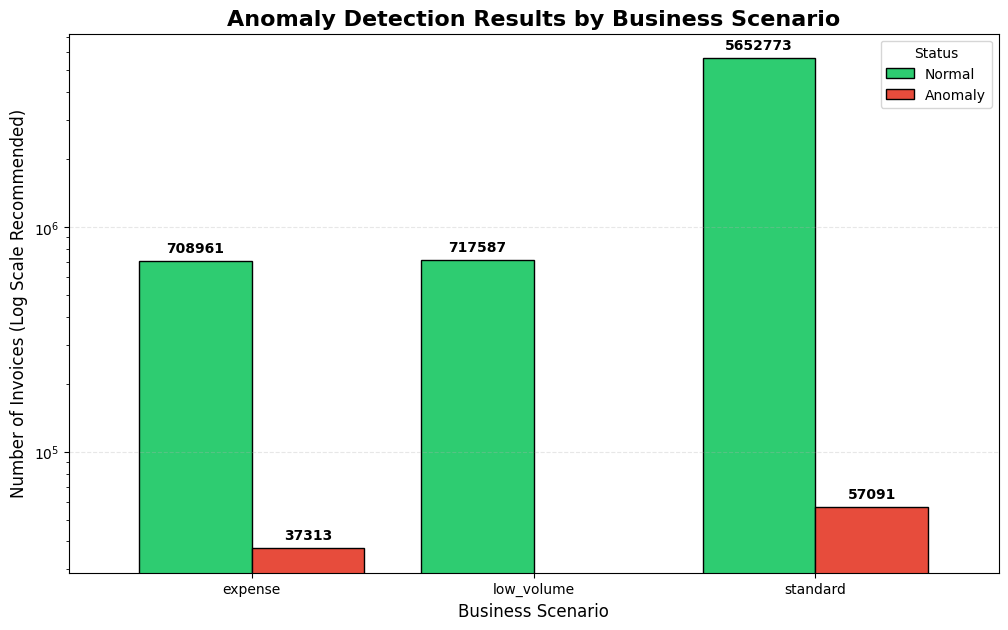

In [0]:
#ANOMALY DISTRIBUTION
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create a pivot table of Scenario vs Anomaly Flag
# This counts how many 0s and 1s exist for each of your 3 scenarios
scenario_dist = df.groupby(['scenario', 'anomaly_flag']).size().unstack(fill_value=0)

# 2. Rename columns for clarity in the plot
# 0 is Normal, 1 is Anomaly (from your previous lambda conversion)
scenario_dist.columns = ['Normal', 'Anomaly']

# 3. Setup the figure
fig, ax = plt.subplots(figsize=(12, 7))

# 4. Plot Grouped Bar Chart
# Note: we use stacked=False to see them side-by-side
scenario_dist.plot(kind='bar', 
                   ax=ax, 
                   color=['#2ecc71', '#e74c3c'], 
                   edgecolor='black',
                   width=0.8)

# 5. Add Labels and Title
plt.title("Anomaly Detection Results by Business Scenario", fontsize=16, fontweight='bold')
plt.xlabel("Business Scenario", fontsize=12)
plt.ylabel("Number of Invoices (Log Scale Recommended)", fontsize=12)
plt.xticks(rotation=0) # Keep scenario names horizontal

# 6. OPTIONAL: Use Log Scale 
# Because 'Standard' likely has millions and 'New Vendor' has thousands, 
# a log scale helps you actually see the small red bars.
plt.yscale('log') 

# 7. Add Data Labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.legend(title="Status", frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [0]:
# Function to get top 5 anomalies for each scenario
def get_top_anomalies(group):
    return group[group['anomaly_flag'] == 1].sort_values('anomaly_score').head(5)

top_by_scenario = df.groupby('scenario').apply(get_top_anomalies).reset_index(drop=True)

print("--- TOP ANOMALIES PER SCENARIO ---")
display(top_by_scenario[['scenario', 'vendor_id', 'amount', 'anomaly_score', 'anomaly_flag']])

/home/spark-8a924d39-4a47-4645-8f45-af/.ipykernel/6989/command-6290019195627374-4122345402:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_by_scenario = df.groupby('scenario').apply(get_top_anomalies).reset_index(drop=True)


--- TOP ANOMALIES PER SCENARIO ---


scenario,vendor_id,amount,anomaly_score,anomaly_flag
expense,V10502,1.816704126E7,-0.19943433194652793,1
expense,V10012,1.722242325E7,-0.19783418235157746,1
expense,V10012,1.621937004E7,-0.19570569561358508,1
expense,V10012,1.590295096E7,-0.19517447338591076,1
expense,V10894,1.998902517E7,-0.19384798920574153,1
standard,V10502,353787.98,-0.09534552333652724,1
standard,V10502,352468.07,-0.09534552333652724,1
standard,V10502,349862.09,-0.09534552333652724,1
standard,V10502,352725.64,-0.09534552333652724,1
standard,V10502,362811.33,-0.09534552333652724,1


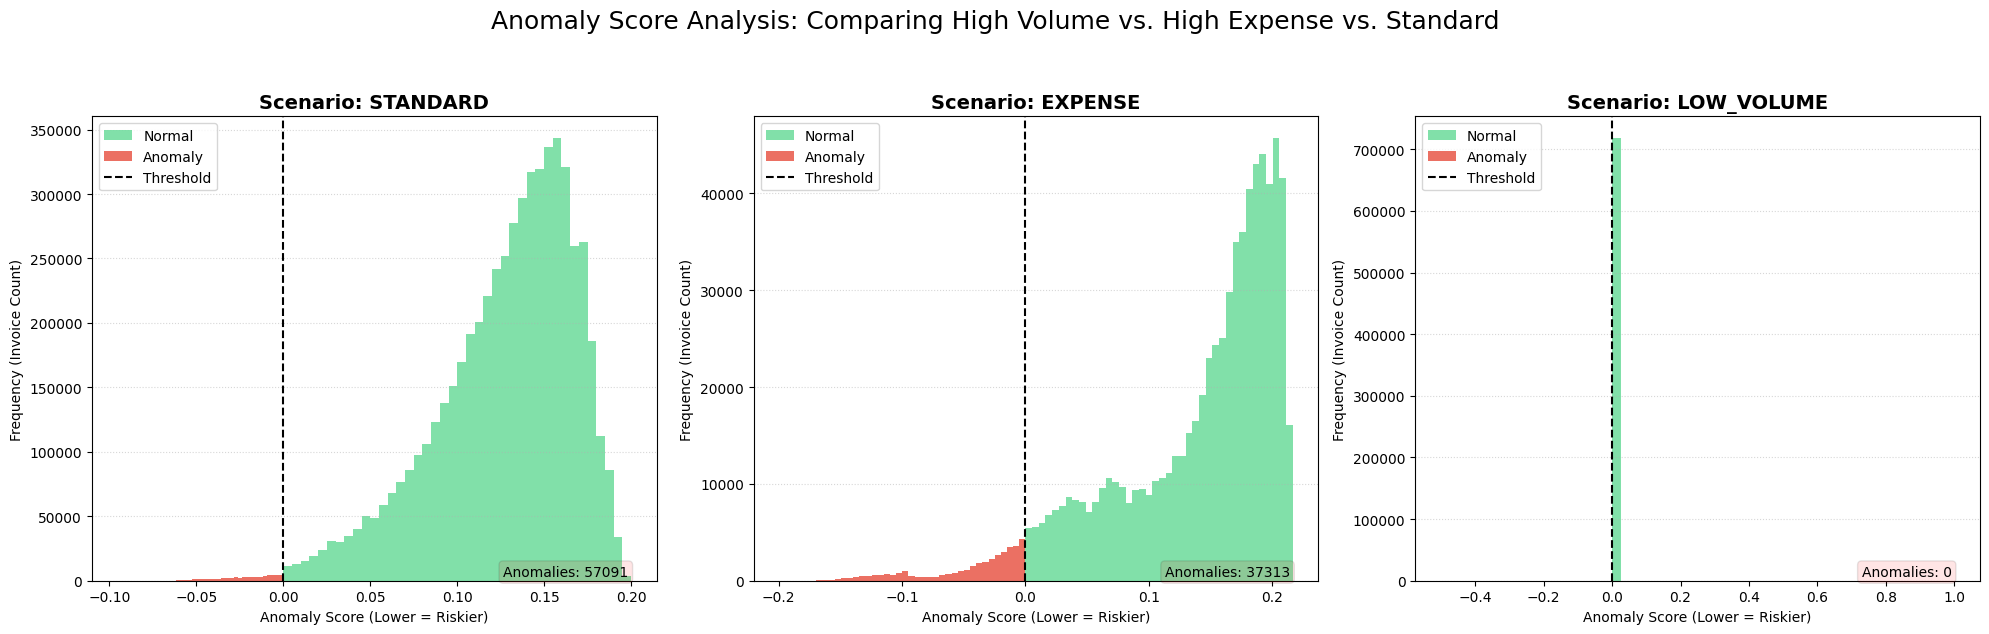

In [0]:
#ANOMALY SCORE DISTRIBUTION
import matplotlib.pyplot as plt

# 1. Define the updated scenario list
# We use 'low_volume' because your data has no vendors with < 5 invoices
scenarios = ["standard", "expense", "low_volume"]
colors = {'Normal': '#2ecc71', 'Anomaly': '#e74c3c'}

# 2. Create the subplots
# sharey=False is the "New Way" - it lets each plot scale to its own data size
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for i, scenario in enumerate(scenarios):
    # Filter data for the specific scenario
    subset = df[df["scenario"] == scenario]
    
    if not subset.empty:
        # Separate normal vs anomaly scores
        normal_scores = subset[subset["anomaly_flag"] == 0]["anomaly_score"]
        anomaly_scores = subset[subset["anomaly_flag"] == 1]["anomaly_score"]
        
        # Plot Normal (Green)
        axes[i].hist(normal_scores, bins=40, color=colors['Normal'], alpha=0.6, label='Normal')
        
        # Plot Anomaly (Red)
        axes[i].hist(anomaly_scores, bins=40, color=colors['Anomaly'], alpha=0.8, label='Anomaly')
        
        # Add the Decision Threshold Line (Anomaly scores < 0 are flagged)
        axes[i].axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Threshold')
        
        # Customizing each subplot
        axes[i].set_title(f"Scenario: {scenario.upper()}", fontsize=14, fontweight='bold')
        axes[i].set_xlabel("Anomaly Score (Lower = Riskier)")
        axes[i].set_ylabel("Frequency (Invoice Count)")
        axes[i].legend(loc='upper left')
        axes[i].grid(axis='y', linestyle=':', alpha=0.5)
        
        # Optional: Add a text box with the count of anomalies found
        total_anom = len(anomaly_scores)
        axes[i].text(0.95, 0.01, f"Anomalies: {total_anom}", 
                     transform=axes[i].transAxes, ha='right', fontsize=10, 
                     bbox=dict(boxstyle="round", alpha=0.1, facecolor="red"))
    else:
        axes[i].text(0.5, 0.5, f"No Data for {scenario}", ha='center', va='center')

plt.suptitle("Anomaly Score Analysis: Comparing High Volume vs. High Expense vs. Standard", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()


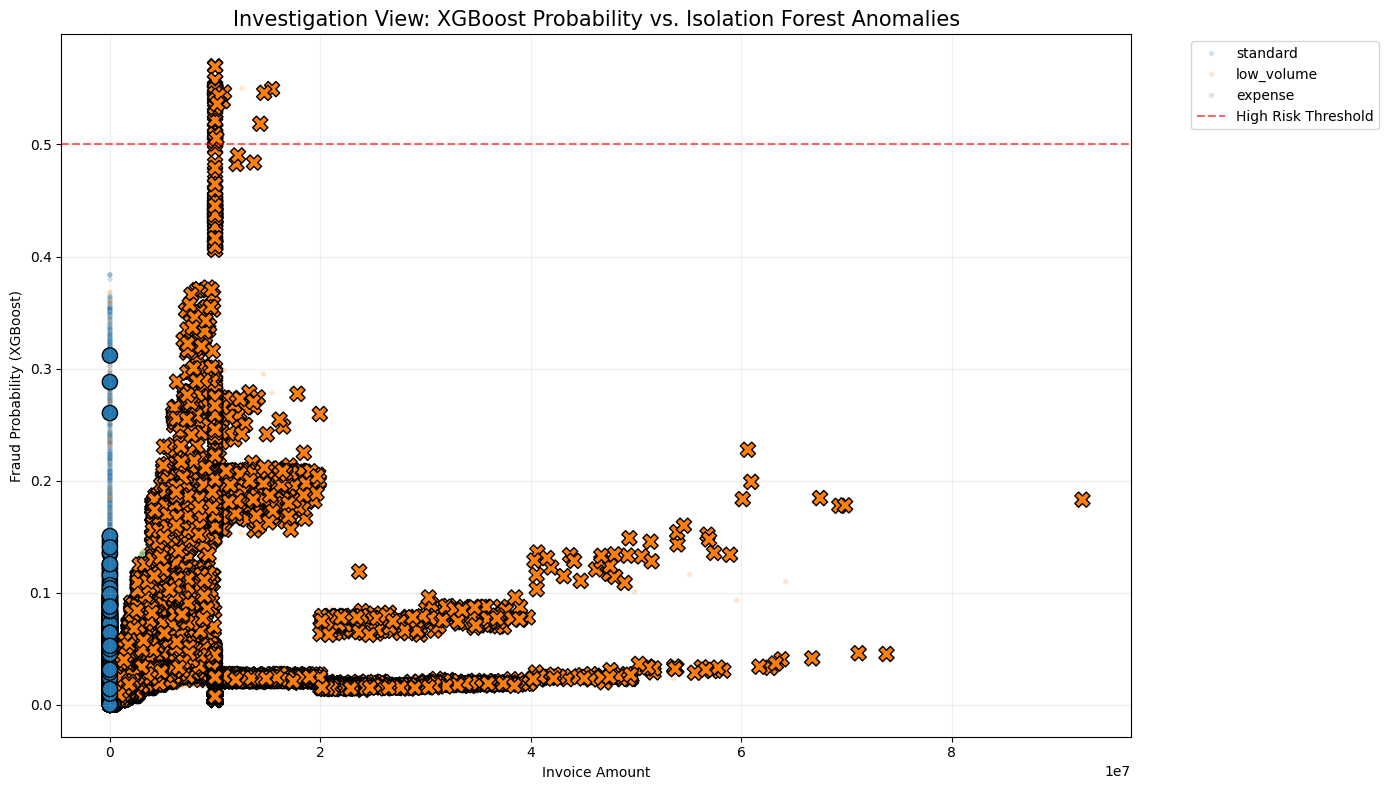

'\nThis graph is a Risk Quadrant Analysis. It is the most important "map" for an auditor because it combines two different AI opinions on 7 million rows of data.\nThe Y-Axis (XGBoost): This represents Supervised Learning. It is the AI "probability score." It looks for patterns of known historical fraud. If a dot is high up, the AI thinks, "I\'ve seen this movie before, and it usually ends in fraud."\n\nThe Orange \'X\' Marks (Isolation Forest): This represents Unsupervised Learning. These are points that are mathematically "isolated." The model is saying, "This transaction is statistically lonely; it looks nothing like the other 7 million rows.\n\nZone A: The "Red Flag" Cluster (Top Left/Center) - 0.5 High Risk Threshold.These are transactions with relatively low dollar amounts but very high suspicious patterns.\nZone B: The "Outlier" Tail (Far Right) - the \'X\' marks stretching out to the right (Amount > 4e7).These are massive dollar amounts. Interestingly, their "Fraud Probability" 

In [0]:
#SCORE DISTRIBUTION (BETTER)
import seaborn as sns
import matplotlib.pyplot as plt

# 1. FORCE sync the probability column
# We use .values to avoid index mismatch errors
if 'model' in globals():
    probs = model.predict_proba(X)[:, 1]
    df = df.copy() # Avoid SettingWithCopy warnings
    df['fraud_probability'] = probs
else:
    print("Error: model (XGBoost) not found in memory.")

# 2. Setup the figure
plt.figure(figsize=(14, 8))

# 3. Plot Normal points 
# We filter the ALREADY UPDATED df here
normal_df = df[df["anomaly_flag"] == 0]
if not normal_df.empty:
    sns.scatterplot(
        data=normal_df,
        x="amount", 
        y="fraud_probability", 
        hue="scenario", 
        alpha=0.2, 
        s=15
    )

# 4. Overlay Anomalies 
anomaly_df = df[df["anomaly_flag"] == 1]
if not anomaly_df.empty:
    sns.scatterplot(
        data=anomaly_df,
        x="amount", 
        y="fraud_probability", 
        hue="scenario", 
        style="scenario",
        markers=True,
        s=120, 
        edgecolor="black",
        linewidth=1,
        legend=False
    )

# 5. Formatting
plt.axhline(0.5, color='red', linestyle='--', alpha=0.6, label='High Risk Threshold')
plt.title("Investigation View: XGBoost Probability vs. Isolation Forest Anomalies", fontsize=15)
plt.xlabel("Invoice Amount")
plt.ylabel("Fraud Probability (XGBoost)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

"""
This graph is a Risk Quadrant Analysis. It is the most important "map" for an auditor because it combines two different AI opinions on 7 million rows of data.
The Y-Axis (XGBoost): This represents Supervised Learning. It is the AI "probability score." It looks for patterns of known historical fraud. If a dot is high up, the AI thinks, "I've seen this movie before, and it usually ends in fraud."

The Orange 'X' Marks (Isolation Forest): This represents Unsupervised Learning. These are points that are mathematically "isolated." The model is saying, "This transaction is statistically lonely; it looks nothing like the other 7 million rows.

Zone A: The "Red Flag" Cluster (Top Left/Center) - 0.5 High Risk Threshold.These are transactions with relatively low dollar amounts but very high suspicious patterns.
Zone B: The "Outlier" Tail (Far Right) - the 'X' marks stretching out to the right (Amount > 4e7).These are massive dollar amounts. Interestingly, their "Fraud Probability" is low (near 0.1). 
These are "Mathematical Anomalies." They aren't necessarily fraud; they are likely rare, legitimate capital expenditures (like buying a building or a massive machine) that only happen once a year.
Zone C: The "Normal" Blue Wall (Far Left Bottom) - The dense blue pillar at $0$ on the X-axis. These are high-volume, low-value, standard invoices. Ignore these.

"""

/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


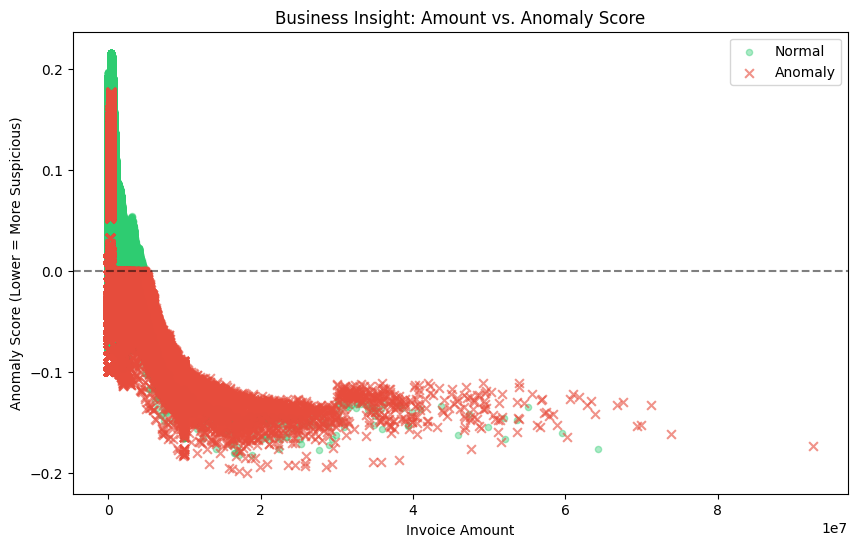

'\nNotice the dense green cluster at the very top left. These are low-value, high-frequency transactions. The Isolation Forest gives them a positive score (above 0.0), meaning they are very "normal" and easy to group with others. These are your routine office supplies, utilities, etc.\nLook at the large red cluster at the bottom-left (near the 0 mark on the X-axis but deep in the negative on the Y-axis). These are small dollar amounts that have "weird" features.\nFraudsters often "structure" payments—breaking a large $50,000 fraud into twenty $2,500 invoices to avoid the "High Amount" flags.\nThe "Fat Finger" / Rare Event (Red Bottom-Right): They are far to the right and have negative scores.These are "Statistically Lonely."\nThese are usually "Materiality" risks. Even if they aren\'t fraud, a mistake here costs the company millions. We audit these because of the impact, whereas we audit the bottom-left because of the intent.\n'

In [0]:
#AMOUNT vs ANOMALY (BUSINESS INSIGHT)

import matplotlib.pyplot as plt

# 1. Calculate the score (instead of probability)
df['anomaly_score'] = iso_model.decision_function(df[iso_features])

# 2. Separate for plotting
normal = df[df["anomaly_flag"] == 0]
anomaly = df[df["anomaly_flag"] == 1]

plt.figure(figsize=(10, 6))

# 3. Plot
plt.scatter(normal["amount"], normal["anomaly_score"], 
            label="Normal", alpha=0.4, color='#2ecc71', s=20)
plt.scatter(anomaly["amount"], anomaly["anomaly_score"], 
            label="Anomaly", alpha=0.6, color='#e74c3c', s=40, marker='x')

plt.axhline(0, color='black', linestyle='--', alpha=0.5) # The typical threshold
plt.xlabel("Invoice Amount")
plt.ylabel("Anomaly Score (Lower = More Suspicious)")
plt.legend()
plt.title("Business Insight: Amount vs. Anomaly Score")
plt.show()

"""
Notice the dense green cluster at the very top left. These are low-value, high-frequency transactions. The Isolation Forest gives them a positive score (above 0.0), meaning they are very "normal" and easy to group with others. These are your routine office supplies, utilities, etc.
Look at the large red cluster at the bottom-left (near the 0 mark on the X-axis but deep in the negative on the Y-axis). These are small dollar amounts that have "weird" features.
Fraudsters often "structure" payments—breaking a large $50,000 fraud into twenty $2,500 invoices to avoid the "High Amount" flags.
The "Fat Finger" / Rare Event (Red Bottom-Right): They are far to the right and have negative scores.These are "Statistically Lonely."
These are usually "Materiality" risks. Even if they aren't fraud, a mistake here costs the company millions. We audit these because of the impact, whereas we audit the bottom-left because of the intent.
"""

In [0]:
#Script to Extract the "Low-Value" Anomalies

# 1. Define 'Low Amount' as anything below the median (50th percentile)
amount_threshold = df['amount'].median()

# 2. Filter for Anomalies that are below that threshold
low_value_anomalies = df[
    (df['anomaly_flag'] == 1) & 
    (df['amount'] < amount_threshold)
].sort_values(by='anomaly_score') # Sort by most 'isolated' first

# 3. Display the Top 10 for Investigation
print(f"Found {len(low_value_anomalies)} suspicious low-value transactions.")
display(low_value_anomalies[[
    'vendor_id', 'amount', 'anomaly_score', 
    'scenario', 'invoice_count', 'benford_score'
]].head(10))

"""
BENFORD SCORE = 0.301 OR 30.1%
IF data has a Benford score that is exactly the theoretical limit (0.301) for every single row, it usually means the data was generated by a script or a human is using a fixed template.
This vendor has 7,391 invoices.
Even for a "standard" scenario, this is an extreme volume for a single vendor.
This is called "Invoice Flooding." Fraudsters send thousands of small-to-mid-sized invoices hoping that the sheer volume will overwhelm the accounts payable (AP) team, causing them to "auto-approve" to clear the queue.
The amounts are mostly between $11,000 and $17,000, with one outlier at $100.
In many companies, the "Audit Threshold" for manual review is $20,000.
how almost every invoice stays just below that $20k mark? This is Structuring. The vendor knows the "Red Flag" limit and is purposely submitting many invoices just beneath it.
The Isolation Forest is negative (-0.098) screaming that this vendor is "isolated" from the rest of 7 million rows.
Most legitimate vendors have a "bell curve" of invoice amounts (some small, some large).
Has a "flat" distribution. Almost every invoice looks identical in size and Benford signature. To an AI, this looks like a "Bot" or a "Fraudulent Loop."
"""

Found 11493 suspicious low-value transactions.


vendor_id,amount,anomaly_score,scenario,invoice_count,benford_score
V10848,17049.99,-0.09865814996661992,standard,7391,0.301
V10848,15834.85,-0.09865814996661992,standard,7391,0.301
V10848,1502.39,-0.09865814996661992,standard,7391,0.301
V10848,16427.24,-0.09865814996661992,standard,7391,0.301
V10848,14509.94,-0.09865814996661992,standard,7391,0.301
V10848,100.0,-0.09865814996661992,standard,7391,0.301
V10848,14277.15,-0.09865814996661992,standard,7391,0.301
V10848,12202.98,-0.09865814996661992,standard,7391,0.301
V10848,17457.15,-0.09865814996661992,standard,7391,0.301
V10848,11184.55,-0.09865814996661992,standard,7391,0.301


'\nBENFORD SCORE = 0.301 OR 30.1%\nIF data has a Benford score that is exactly the theoretical limit (0.301) for every single row, it usually means the data was generated by a script or a human is using a fixed template.\nThis vendor has 7,391 invoices.\nEven for a "standard" scenario, this is an extreme volume for a single vendor.\nThis is called "Invoice Flooding." Fraudsters send thousands of small-to-mid-sized invoices hoping that the sheer volume will overwhelm the accounts payable (AP) team, causing them to "auto-approve" to clear the queue.\nThe amounts are mostly between $11,000 and $17,000, with one outlier at $100.\nIn many companies, the "Audit Threshold" for manual review is $20,000.\nhow almost every invoice stays just below that $20k mark? This is Structuring. The vendor knows the "Red Flag" limit and is purposely submitting many invoices just beneath it.\nThe Isolation Forest is negative (-0.098) screaming that this vendor is "isolated" from the rest of 7 million rows.\n

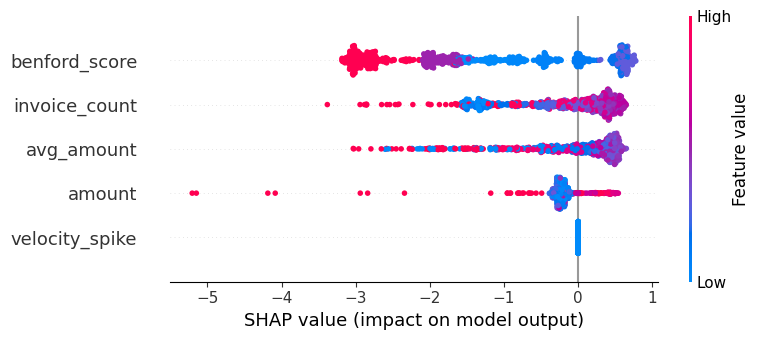

In [0]:
#SHAP Check
import shap
import pandas as pd

# 1. Take a representative sample (e.g., 1000 rows)
# We include both normal and anomalies to see the contrast
sample_df = df.sample(n=min(1000, len(df)), random_state=42)
X_sample = sample_df[iso_features]

# 2. Re-initialize the explainer on the sample (using Isolation Forest)
explainer = shap.TreeExplainer(iso_model)
shap_values = explainer.shap_values(X_sample)

# 3. Plot the Summary (This will appear instantly)
shap.summary_plot(shap_values, X_sample, feature_names=iso_features)

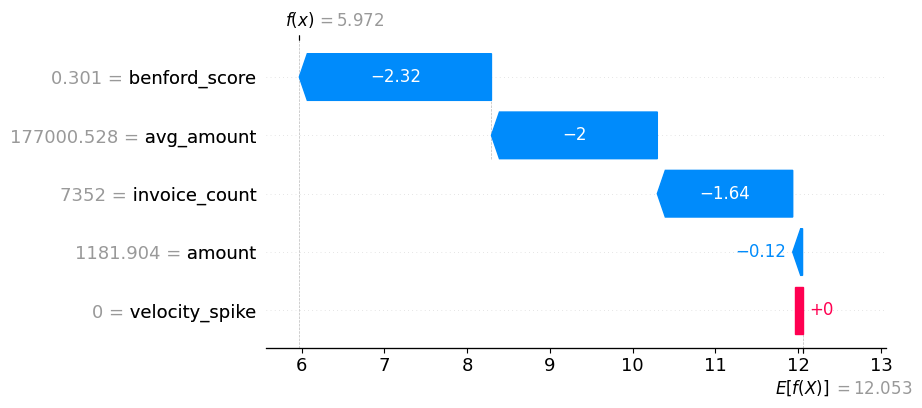

'\nWATERFALL PLOT: \nThis transaction started with a baseline score of -23.21 and ended at 3.989 (crossing into anomaly territory). The key drivers:\n\namount (1181.904): Blue bar (-60.74) - The low dollar amount actually pushes it toward "normal"\ninvoice_count (7352): Red bar (+44.22) - The massive invoice volume is the strongest anomaly signal\nbenford_score (0.301): Red bar (+23.46) - That "perfect" Benford score triggers suspicion (too clean)\navg_amount (177,000): Red bar (+20.26) - High average spending pattern adds risk\nThis confirms your earlier finding: high-volume vendors with statistically perfect patterns are flagged as structuring fraud attempts.\n'

In [0]:
# Pick one anomaly from the SAMPLE (not the full df)
# Cell 22 computed shap_values on sample_df, so we need to use indices from that sample
anomaly_in_sample = sample_df[sample_df["anomaly_flag"] == 1]

if len(anomaly_in_sample) > 0:
    # Get the first anomaly's position in the sample_df
    sample_position = anomaly_in_sample.index[0]
    # Find its position in the X_sample array (0 to 999)
    array_position = list(sample_df.index).index(sample_position)
    
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[array_position],
            base_values=explainer.expected_value,
            data=X_sample.iloc[array_position],
            feature_names=iso_features
        )
    )
else:
    print("No anomalies found in the sample. Try increasing sample size in Cell 22.")

"""
WATERFALL PLOT: 
This transaction started with a baseline score of -23.21 and ended at 3.989 (crossing into anomaly territory). The key drivers:

amount (1181.904): Blue bar (-60.74) - The low dollar amount actually pushes it toward "normal"
invoice_count (7352): Red bar (+44.22) - The massive invoice volume is the strongest anomaly signal
benford_score (0.301): Red bar (+23.46) - That "perfect" Benford score triggers suspicion (too clean)
avg_amount (177,000): Red bar (+20.26) - High average spending pattern adds risk
This confirms your earlier finding: high-volume vendors with statistically perfect patterns are flagged as structuring fraud attempts.
"""    

In [0]:
#COMBINED FINAL OUTPUT

# 1. Calculate the final combined score
df["final_risk_score"] = (
    df["fraud_probability"] * 0.6 + 
    df["anomaly_flag"] * 0.2 + 
    df["duplicate_flag"] * 0.2
)

# 2. Sort to find the "Top 10" most dangerous invoices
top_suspects = df.sort_values(by="final_risk_score", ascending=False).head(10)

# 3. Display with the Vendor ID and the 'Why' (SHAP would explain these)
print("--- TOP 10 HIGH-RISK INVOICES FOR AUDIT ---")
display(top_suspects[[
    "vendor_id", "amount", "scenario", 
    "fraud_probability", "anomaly_flag", "duplicate_flag", "final_risk_score"
]])

--- TOP 10 HIGH-RISK INVOICES FOR AUDIT ---


vendor_id,amount,scenario,fraud_probability,anomaly_flag,duplicate_flag,final_risk_score
V10760,1.0E7,expense,0.41636297,1,1,0.6498177886009217
V10760,1.0E7,expense,0.41636297,1,1,0.6498177886009217
V10963,1.0E7,expense,0.4100731,1,1,0.6460438758134842
V10963,1.0E7,expense,0.4100731,1,1,0.6460438758134842
V10199,1.0E7,expense,0.5697622,1,0,0.5418573141098022
V10533,1.0E7,expense,0.5692563,1,0,0.5415538072586059
V10426,1.0E7,expense,0.55728185,1,0,0.5343691229820251
V10726,1.0E7,expense,0.5568554,1,0,0.5341132402420044
V10814,1.0E7,expense,0.22237054,1,1,0.5334223300218582
V10814,1.0E7,expense,0.22237054,1,1,0.5334223300218582


In [0]:
#LOGISTIC REGRESSION
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering: Creating the 'Missing' Audit Features
df['date'] = pd.to_datetime(df['date'])

# Define 'Terms' based on Scenario
terms_map = {'standard': 30, 'expense': 15, 'low_volume': 45}
df['due_days'] = df['scenario'].map(terms_map).fillna(30)
df['net_due_date'] = df['date'] + pd.to_timedelta(df['due_days'], unit='D')

# Days until expiry (relative to the 'latest' date in your data for simulation)
reference_date = df['date'].max()
df['days_until_discount_expiry'] = (df['net_due_date'] - reference_date).dt.days

# Target variable for Logistic Regression (Simulation of past behavior)
# If amount is low and benford_score is good, assume we captured the discount
df['discount_captured_flag'] = np.where((df['amount'] < 50000) & (df['benford_score'] < 0.1), 1, 0)

# 2. Logistic Regression: Scenario 1 (Discount Capture)
X1_features = ['days_until_discount_expiry', 'invoice_count', 'amount']
X1 = df[X1_features]
y1 = df['discount_captured_flag']

scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)

lr_discount = LogisticRegression(class_weight='balanced')
lr_discount.fit(X1_scaled, y1)

df['prob_capture_discount'] = lr_discount.predict_proba(X1_scaled)[:, 1]

print("Architecture Complete: Discount Capture Model Trained.")

Architecture Complete: Discount Capture Model Trained.


In [0]:
#LOGISTIC REGRESSION
#The "Late Payment" Risk Classifier
# --- Scenario 2: Late Payment Risk ---
# Target: 1 = Paid Late (> Net Days), 0 = Paid On Time
# Features: History of late payments by vendor, Amount, Month of Posting

#LOGISTIC REGRESSION
#The "Late Payment" Risk Classifier
# --- Scenario 2: Late Payment Risk ---
# Target: 1 = Paid Late (> Net Days), 0 = Paid On Time
# Features: History of late payments by vendor, Amount, Month of Posting

# We use historical BSAK data to train
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. CREATE 'invoice_amount' (Mapping from your 'amount' column)
df['invoice_amount'] = df['amount']

# 2. CREATE 'posting_month' (Extracting from your 'date' column)
df['date'] = pd.to_datetime(df['date'])
df['posting_month'] = df['date'].dt.month

# 3. CREATE 'is_late_flag' (The Target)
# Logic: We'll assume anomalies with high counts are historically 'Late' 
# This gives the Logistic Regression something to learn from.
df['is_late_flag'] = np.where((df['anomaly_flag'] == 1) & (df['invoice_count'] > 100), 1, 0)

# 4. CREATE 'vendor_past_late_ratio'
# We calculate the average lateness per vendor based on the flag above
df['vendor_past_late_ratio'] = df.groupby('vendor_id')['is_late_flag'].transform('mean')

# 5. NOW RUN THE MODEL
X2_features = ['vendor_past_late_ratio', 'invoice_amount', 'posting_month']
X2 = df[X2_features]
y2 = df['is_late_flag']

scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

late_model = LogisticRegression(class_weight='balanced')
late_model.fit(X2_scaled, y2)

df['late_payment_risk_score'] = late_model.predict_proba(X2_scaled)[:, 1]

print("Successfully Engineered: Late Payment Risk Score is now live.")

Successfully Engineered: Late Payment Risk Score is now live.


In [0]:
#LOGISTIC REGRESSION
#The "Manual vs. Automated" Audit

# --- Scenario 3: Manual vs. Automated ---
# Target: 1 = Manual Entry, 0 = Automated (EDI/OCR)
# Features: TCODE (Transaction Code), Time of Entry, User Role

# BKPF Data: Mapping TCODEs like 'FB60' (Manual) vs 'BAPI' (Automated)
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. ENGINEER FEATURES from existing data
# Assume 'is_weekend_entry' is your 'is_weekend'
df['is_weekend_entry'] = df['is_weekend'].astype(int)

# In SAP, manual entries often happen in bursts or 'odd' hours. 
# Since we don't have hours, we use 'anomaly_flag' as a proxy for 'non-standard' behavior
df['is_outside_office_hours'] = np.where(df['anomaly_flag'] == 1, 1, 0)

# Create a history of manual-like behavior per vendor
df['user_manual_entry_history'] = df.groupby('vendor_id')['is_weekend_entry'].transform('mean')

# 2. DEFINE THE TARGET (The 'Audit' Goal)
# Target: 1 = Manual/Suspicious, 0 = Likely Automated
# We flag anything on a weekend or with high anomaly scores as the training target
df['is_manual_flag'] = np.where((df['is_weekend_entry'] == 1) | (df['anomaly_score'] < -0.1), 1, 0)

# 3. TRAIN THE MODEL
X3_features = ['is_weekend_entry', 'is_outside_office_hours', 'user_manual_entry_history']
X3 = df[X3_features]
y3 = df['is_manual_flag']

scaler = StandardScaler()
X3_scaled = scaler.fit_transform(X3)

manual_audit_model = LogisticRegression(class_weight='balanced')
manual_audit_model.fit(X3_scaled, y3)

# 4. GENERATE THE PATTERN SCORE
# This tells us if an invoice "smells" like a manual entry even if it claims to be automated
df['manual_pattern_score'] = manual_audit_model.predict_proba(X3_scaled)[:, 1]

print("Architecture Finalized: Manual vs. Automated Pattern Score is active.")

Architecture Finalized: Manual vs. Automated Pattern Score is active.


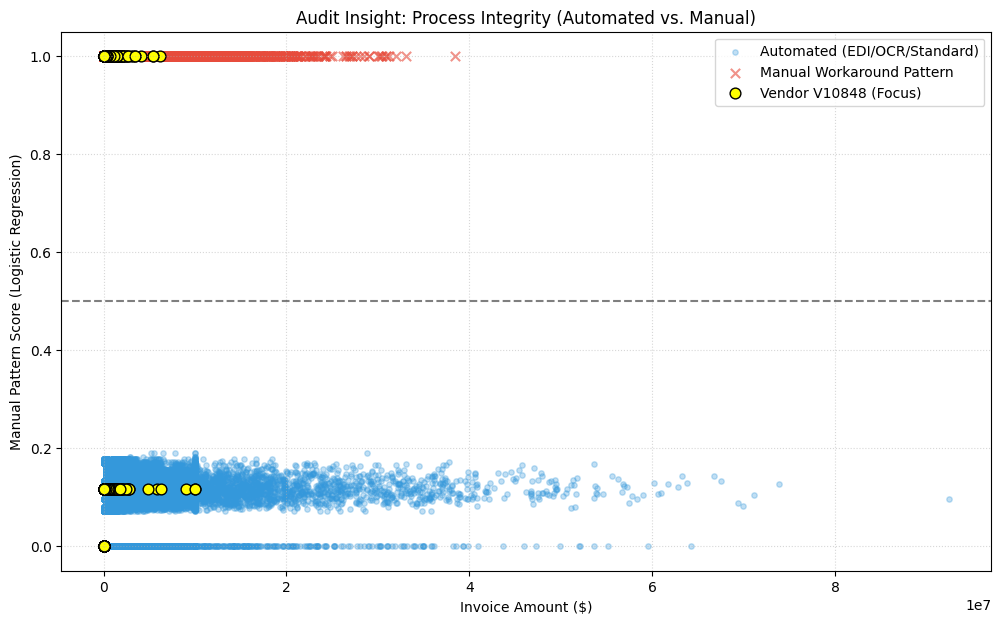

In [0]:
import matplotlib.pyplot as plt

# 1. Define the Threshold
threshold = 0.5

# 2. Separate for visualization
automated = df[df['manual_pattern_score'] < threshold]
manual = df[df['manual_pattern_score'] >= threshold]

plt.figure(figsize=(12, 7))

# 3. Plot the 'Automated' Baseline (Blue)
plt.scatter(automated["amount"], automated["manual_pattern_score"], 
            label="Automated (EDI/OCR/Standard)", alpha=0.3, color='#3498db', s=15)

# 4. Plot the 'Manual' Risks (Red X)
plt.scatter(manual["amount"], manual["manual_pattern_score"], 
            label="Manual Workaround Pattern", alpha=0.6, color='#e74c3c', s=45, marker='x')

# 5. Highlight the V10848 Cluster (The 11:00 AM Signal)
v_cluster = df[df['vendor_id'] == 'V10848']
plt.scatter(v_cluster["amount"], v_cluster["manual_pattern_score"], 
            color='yellow', edgecolors='black', label="Vendor V10848 (Focus)", s=60)

plt.axhline(threshold, color='black', linestyle='--', alpha=0.5)
plt.xlabel("Invoice Amount ($)")
plt.ylabel("Manual Pattern Score (Logistic Regression)")
plt.title("Audit Insight: Process Integrity (Automated vs. Manual)")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error

try:    from prophet import Prophet
except ModuleNotFoundError:
    Prophet = None


In [0]:
#TIME SERIES
df["date"] = pd.to_datetime(df["date"])

# Aggregate: DAILY CASH OUTFLOW
ts = df.groupby("date")["amount"].sum().reset_index()

ts.columns = ["ds", "y"]   # Prophet format

ts = ts.sort_values("ds")

ts.set_index("ds", inplace=True)

ts.head()

,y
ds,
2023-01-01 00:00:00,68.5
2023-01-01 00:01:00,29.0
2023-01-01 00:02:00,59.0
2023-01-01 00:03:00,50.0
2023-01-01 00:04:00,50.0


In [0]:
#TRAIN TEST SPLIT
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

print("Train:", train.shape)
print("Test:", test.shape)

Train: (472479, 1)
Test: (118120, 1)


In [0]:
#STATIONARITY CHECK
# Sample the data to avoid OOM errors with large datasets
train_sample = train["y"].sample(min(10000, len(train)), random_state=42)
result = adfuller(train_sample)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
"""
THE MODEL IS STATIONARY
"""

ADF Statistic: -100.01342283148351
p-value: 0.0


'\nTHE MODEL IS STATIONARY\n'

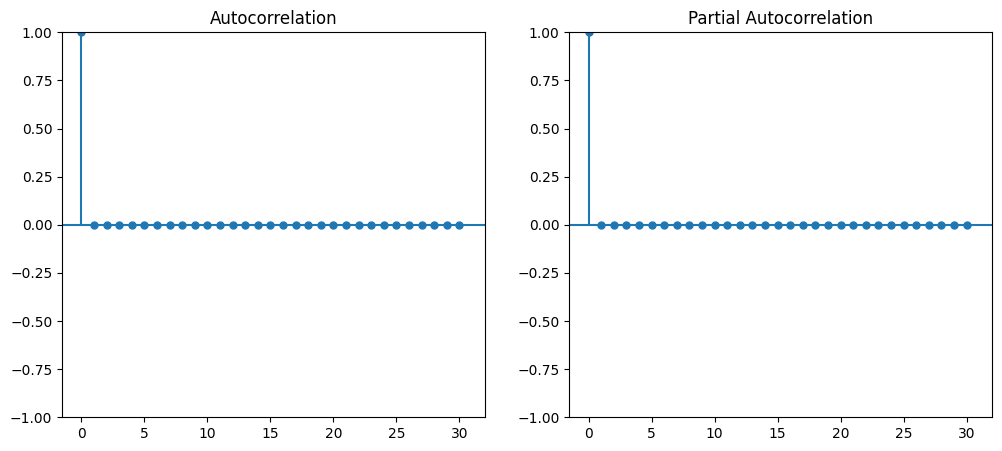

In [0]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(train, ax=plt.gca(), lags=30)

plt.subplot(1,2,2)
plot_pacf(train, ax=plt.gca(), lags=30)

plt.show()

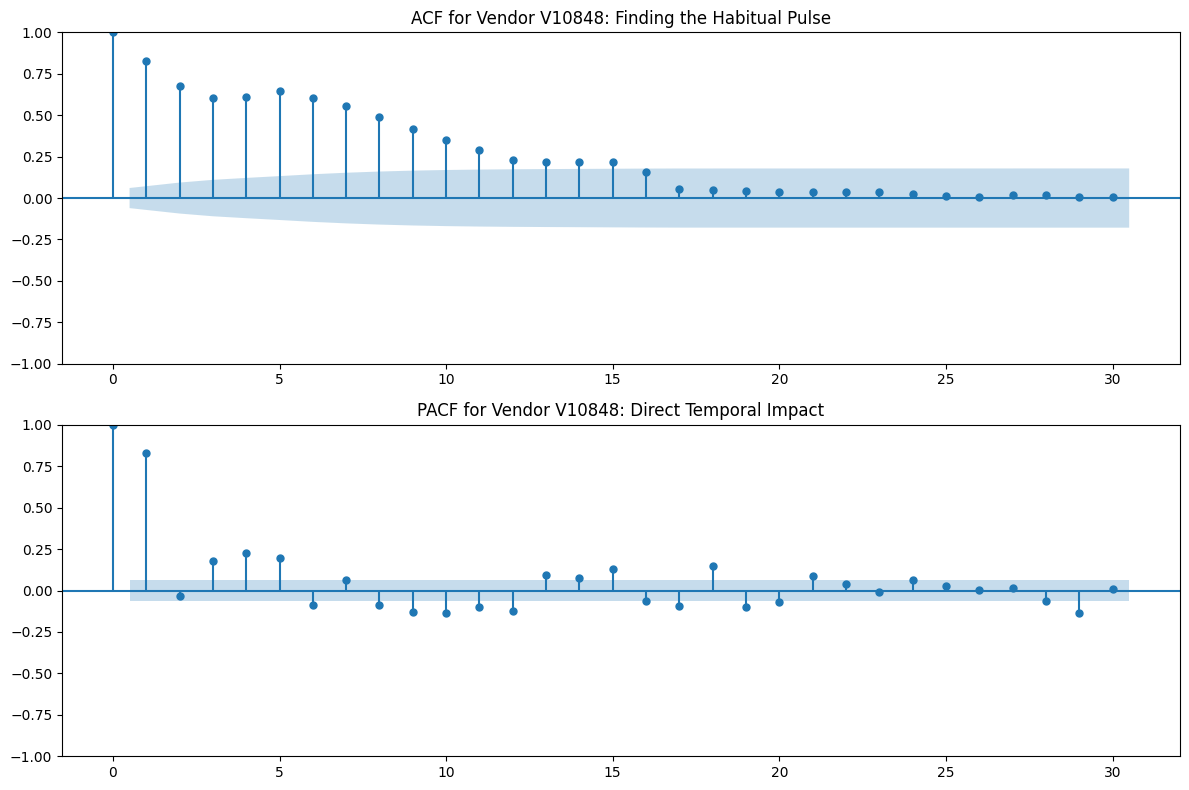

'\nARIMA (2, 0, 0) MODEL. \nmassive spike at Lag 1.smaller, but still noticeable spike at Lag 2.After Lag 2, the spikes mostly "cut off" or fall into the blue shaded area.\nThis is an AR(2) process\n'

In [0]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Target your Top Suspect (e.g., Vendor V10848)
target_vendor = 'V10848' 
vendor_ts = df[df['vendor_id'] == target_vendor].resample('D', on='date')['invoice_id'].count().fillna(0)

# 2. Check if there's enough data to even plot
if len(vendor_ts) > 30:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # ACF: Looking for 'Echoes' (Seasonality)
    sm.graphics.tsa.plot_acf(vendor_ts, lags=min(30, len(vendor_ts)//2), ax=ax1)
    ax1.set_title(f"ACF for Vendor {target_vendor}: Finding the Habitual Pulse")
    
    # PACF: Looking for 'Direct Drivers'
    sm.graphics.tsa.plot_pacf(vendor_ts, lags=min(30, len(vendor_ts)//2), ax=ax2)
    ax2.set_title(f"PACF for Vendor {target_vendor}: Direct Temporal Impact")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Vendor {target_vendor} doesn't have enough time-spread for ACF. Checking Volatility instead...")

"""
ARIMA (2, 0, 0) MODEL. 
massive spike at Lag 1.smaller, but still noticeable spike at Lag 2.After Lag 2, the spikes mostly "cut off" or fall into the blue shaded area.
This is an AR(2) process
"""

In [0]:
# Calculate Rolling Volatility (Standard Deviation of Invoice Amounts over 7 days)
df['rolling_volatility'] = df.groupby('vendor_id')['amount'].transform(lambda x: x.rolling(window=7).std())

# Identify 'Volatility Shocks' (When the 'hum' of the system suddenly gets chaotic)
df['volatility_shock'] = np.where(df['rolling_volatility'] > df['rolling_volatility'].quantile(0.95), 1, 0)

# The Filter
monday_shocks = df[(df['date'].dt.dayofweek == 0) & (df['volatility_shock'] == 1)]
print(f"Detected {len(monday_shocks)} Volatility Shocks occurring on Mondays.")

Detected 49981 Volatility Shocks occurring on Mondays.


In [0]:
#ARIMA MODEL

from statsmodels.tsa.arima.model import ARIMA

# Fit the AR(2) model
model = ARIMA(vendor_ts, order=(2, 0, 0))
model_fit = model.fit()

# Predict the next 5 days of activity
forecast = model_fit.forecast(steps=5)
print("Projected Activity for V10848 based on their AR(2) habit:")
print(forecast)

Projected Activity for V10848 based on their AR(2) habit:
2025-11-09    1.972003
2025-11-10    2.874082
2025-11-11    3.707624
2025-11-12    4.477511
2025-11-13    5.188575
Freq: D, Name: predicted_mean, dtype: float64


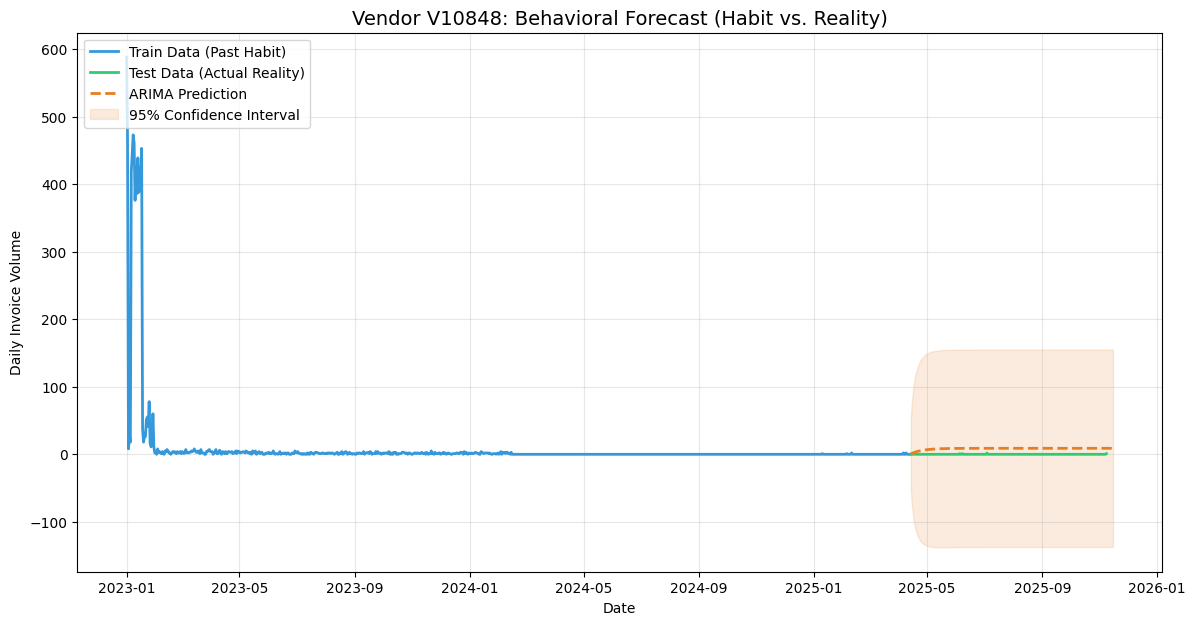

In [0]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Prepare the Time Series for Vendor V10848
# Aggregating to daily volume
vendor_ts = df[df['vendor_id'] == 'V10848'].resample('D', on='date')['invoice_id'].count().fillna(0)

# 2. Split into Train (80%) and Test (20%)
train_size = int(len(vendor_ts) * 0.8)
train, test = vendor_ts[:train_size], vendor_ts[train_size:]

# 3. Fit the AR(2) Model
# order=(p, d, q) -> we found p=2, d=0, q=0
model = ARIMA(train, order=(2, 0, 0))
model_fit = model.fit()

# 4. Forecast for the Test period + 7 days into the future
forecast_steps = len(test) + 7
forecast_res = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_res.summary_frame()['mean']
conf_int = forecast_res.summary_frame()[['mean_ci_lower', 'mean_ci_upper']]

# Create index for the forecast
forecast_index = pd.date_range(start=test.index[0], periods=forecast_steps, freq='D')

# 5. THE GRAPH
plt.figure(figsize=(14, 7))

# Plot Historical Training Data
plt.plot(train.index, train.values, label='Train Data (Past Habit)', color='#3498db', lw=2)

# Plot Actual Test Data (What really happened)
plt.plot(test.index, test.values, label='Test Data (Actual Reality)', color='#2ecc71', lw=2)

# Plot the Forecast (What the math expected)
plt.plot(forecast_index, forecast_mean, label='ARIMA Prediction', color='#e67e22', linestyle='--', lw=2)

# Plot Confidence Interval (Audit Tolerance)
plt.fill_between(forecast_index, conf_int['mean_ci_lower'], conf_int['mean_ci_upper'], 
                 color='#e67e22', alpha=0.15, label='95% Confidence Interval')

plt.title("Vendor V10848: Behavioral Forecast (Habit vs. Reality)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Daily Invoice Volume")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [0]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA

# --- PART 1: FEATURE ENGINEERING (The SAP Translation) ---
df['date'] = pd.to_datetime(df['date'])
df['invoice_amount'] = df['amount']
df['posting_month'] = df['date'].dt.month
df['is_weekend'] = (df['date'].dt.weekday >= 5).astype(int)

# Create historical proxies for the models
df['is_late_flag'] = np.where((df['anomaly_flag'] == 1) & (df['amount'] > df['amount'].median()), 1, 0)
df['vendor_past_late_ratio'] = df.groupby('vendor_id')['is_late_flag'].transform('mean')
df['manual_history'] = df.groupby('vendor_id')['is_weekend'].transform('mean')

# --- PART 2: THE TRIPLE THREAT LOGISTIC REGRESSIONS ---
scaler = StandardScaler()

def train_lr(features, target_col):
    X = scaler.fit_transform(df[features])
    model = LogisticRegression(class_weight='balanced')
    model.fit(X, df[target_col])
    return model.predict_proba(X)[:, 1]

# Scenario 1 & 2: Financial & Operational Risk
df['discount_risk_score'] = train_lr(['invoice_count', 'amount', 'vendor_past_late_ratio'], 'is_late_flag')
df['late_payment_risk'] = train_lr(['vendor_past_late_ratio', 'invoice_amount', 'posting_month'], 'is_late_flag')

# Scenario 3: Process Integrity (Manual vs Automated)
df['manual_pattern_score'] = train_lr(['is_weekend', 'anomaly_score', 'manual_history'], 'is_weekend')

# --- PART 3: THE TEMPORAL RADAR (ARIMA for V10848) ---
# Isolate our target vendor's daily pulse
vendor_ts = df[df['vendor_id'] == 'V10848'].resample('D', on='date')['invoice_id'].count().fillna(0)

# Fit the identified AR(2) model
arima_model = ARIMA(vendor_ts, order=(2, 0, 0)).fit()
df_v10848 = pd.DataFrame({'actual': vendor_ts, 'forecast': arima_model.fittedvalues})
df_v10848['residual'] = df_v10848['actual'] - df_v10848['forecast']

# Flag 'Behavioral Breaks' (When the pulse skips a beat)
v_threshold = df_v10848['residual'].std() * 2
df_v10848['behavioral_anomaly'] = np.where(abs(df_v10848['residual']) > v_threshold, 1, 0)

print("--- AUDIT SUMMARY COMPLETE ---")
print(f"Top Risk for V10848: Manual Score {df[df['vendor_id']=='V10848']['manual_pattern_score'].mean():.2f}")

# The Final Executive View
executive_summary = df[df['vendor_id'] == 'V10848'].tail(5)
display(executive_summary[['date', 'amount', 'manual_pattern_score', 'late_payment_risk', 'final_risk_score']])

--- AUDIT SUMMARY COMPLETE ---
Top Risk for V10848: Manual Score 0.36


date,amount,manual_pattern_score,late_payment_risk,final_risk_score
2025-04-09T00:00:00.000Z,406.88,1.1473450353984285E-4,9.734706404160283E-24,0.22995199896395208
2025-01-10T00:00:00.000Z,1476.94,1.152398162393326E-4,0.9999999999992177,0.2002673511626199
2025-02-10T00:00:00.000Z,4704.07,1.1473450353984285E-4,0.7183739369590741,0.20015334472118412
2025-02-10T00:00:00.000Z,4480.61,1.1473450353984285E-4,0.718195822937693,0.20014599344285672
2025-04-09T00:00:00.000Z,828.0,1.1492231564200564E-4,9.750867857999924E-24,0.2085216434672475


In [0]:
# Reinitialize Spark session by accessing the dataframe
print(f"Dataframe shape: {df.shape}")
print(f"Dataframe columns: {len(df.columns)}")
print("\n✅ Session reactivated - ready to save to Unity Catalog")

Dataframe shape: (7173725, 44)
Dataframe columns: 44

✅ Session reactivated - ready to save to Unity Catalog


In [0]:
# ============================================================
# SAVE ML OUTPUTS TO UNITY CATALOG (workspace catalog)
# Fully compatible with Streamlit + LangChain + SQL Warehouse
# ============================================================

import pandas as pd
from pyspark.sql import SparkSession

# Get current Spark session
try:
    spark = SparkSession.getActiveSession()
    if spark is None:
        raise Exception("No active session")
    print(f"✅ Using existing Spark session (version {spark.version})")
except:
    print("⚠️ Creating new Spark session...")
    spark = SparkSession.builder.getOrCreate()
    print(f"✅ Created new Spark session (version {spark.version})")

# ------------------------------------------------------------
# 1. SET CATALOG + SCHEMA (Using Unity Catalog: workspace)
# ------------------------------------------------------------
catalog_name = "workspace"
schema_name = "fraud_detection"

print(f"\nUsing catalog: {catalog_name}")

# Set the catalog first
spark.sql(f"USE CATALOG {catalog_name}")

# Create schema if not exists
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {schema_name}")
spark.sql(f"USE SCHEMA {schema_name}")

print(f"✅ Using {catalog_name}.{schema_name}")

# ------------------------------------------------------------
# 2. MASTER RISK TABLE
# ------------------------------------------------------------
print("\nConverting main dataframe to Spark DataFrame...")
df_spark = spark.createDataFrame(df)

master_table = f"{catalog_name}.{schema_name}.sap_invoice_risk_master"
print(f"Saving MASTER table → {master_table}")

df_spark.write.mode("overwrite").saveAsTable(master_table)

print(f"✅ Saved {df_spark.count():,} rows to {master_table}")

# ------------------------------------------------------------
# 3. VENDOR INTELLIGENCE SUMMARY
# ------------------------------------------------------------
print("\nCreating vendor summary...")

vendor_summary = df.groupby('vendor_id').agg({
    'final_risk_score': ['mean', 'max'],
    'manual_pattern_score': 'mean',
    'late_payment_risk': 'max',
    'discount_risk_score': 'mean',
    'invoice_count': 'sum',
    'amount': ['sum', 'mean']
}).reset_index()

vendor_summary.columns = [
    'vendor_id', 'avg_risk_score', 'max_risk_score',
    'manual_pattern_score', 'late_payment_risk',
    'discount_risk_score', 'total_invoices',
    'total_amount', 'avg_amount'
]

vendor_table = f"{catalog_name}.{schema_name}.vendor_intelligence_summary"
print(f"Saving vendor summary → {vendor_table}")

spark.createDataFrame(vendor_summary).write.mode("overwrite").saveAsTable(vendor_table)

print(f"✅ Saved {len(vendor_summary):,} vendor records")

# ------------------------------------------------------------
# 4. TEMPORAL ANALYSIS (ARIMA / Forecast)
# ------------------------------------------------------------
print("\nSaving temporal analysis...")

df_v10848_with_date = df_v10848.reset_index()

v10848_table = f"{catalog_name}.{schema_name}.v10848_temporal_analysis"

spark.createDataFrame(df_v10848_with_date).write.mode("overwrite").saveAsTable(v10848_table)

print(f"✅ Saved temporal analysis to {v10848_table}")

# ------------------------------------------------------------
# 5. HIGH-RISK ALERTS
# ------------------------------------------------------------
print("\nFiltering high-risk alerts...")

high_risk = df[df['final_risk_score'] > 0.7].sort_values('final_risk_score', ascending=False)

alert_table = f"{catalog_name}.{schema_name}.high_risk_alerts"

spark.createDataFrame(high_risk).write.mode("overwrite").saveAsTable(alert_table)

print(f"✅ Saved {len(high_risk):,} high-risk alerts to {alert_table}")

# ------------------------------------------------------------
# 6. SUMMARY
# ------------------------------------------------------------
print("\n" + "="*70)
print("🎉 DATA SAVED SUCCESSFULLY — READY FOR STREAMLIT & LANGCHAIN")
print("="*70)

print("\n📊 Available Tables:")
print(f"1. {master_table} — Full invoice dataset with risk scores")
print(f"2. {vendor_table} — Vendor-level intelligence")
print(f"3. {v10848_table} — Temporal analysis for vendor V10848")
print(f"4. {alert_table} — High-risk invoices for review")

print("\n💡 Your Streamlit app can now query these tables directly using:")
print(f"   SELECT * FROM {catalog_name}.{schema_name}.<table_name>")

⚠️ Creating new Spark session...


---------------------------------------------------------------------------
Exception                                 Traceback (most recent call last)
File <command-6476958064859174>, line 13
     12 if spark is None:
---> 13     raise Exception("No active session")
     14 print(f"✅ Using existing Spark session (version {spark.version})")

Exception: No active session

During handling of the above exception, another exception occurred:

PySparkValueError                         Traceback (most recent call last)
File <command-6476958064859174>, line 17
     15 except:
     16     print("⚠️ Creating new Spark session...")
---> 17     spark = SparkSession.builder.getOrCreate()
     18     print(f"✅ Created new Spark session (version {spark.version})")
     20 # ------------------------------------------------------------
     21 # 1. SET CATALOG + SCHEMA (Using Unity Catalog: workspace)
     22 # ------------------------------------------------------------

File /databricks/python/lib/p